In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
from esem import rf_model
# from eofs.xarray import Eof
# import itertools
# import joblib  # Efficient for saving large models
# from utils import *


In [225]:
train_files= ['ssp126', 'ssp585', 'picontrol']

In [ ]:
NEOFS = 5 # for testing

Xtrain, eof_solvers, mean, std = get_Xtrain(train_files, NEOFS)

Ytrain = get_Ytrain(train_files)
Ytrain_yield = Ytrain['mai'].values.reshape(-1, 360*720)

Xtest = get_Xtest('ssp370', eof_solvers, mean, std)

Ytest = get_Ytest('ssp370')
yield_truth = Ytest['mai']

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [203]:
training_data_path = './inputs/'

def get_Xtrain(datasets, n_eofs=5):
    """
    Args:
        datasets list(str): dataset to create features for
        n_eofs (int): number of eofs to create
    """
    
    if isinstance(datasets, str):
        datasets = [datasets]
        
    X = xr.concat([xr.open_dataset(training_data_path+f'inputs_{d}.nc') for d in datasets], dim='time')
    X = X.assign_coords(time=np.arange(len(X.time)))
    
    # # compute eofs for pr
    # pr_solver = Eof(X['pr'])
    # pr_eofs = pr_solver.eofsAsCorrelation(neofs=n_eofs)
    # pr_pcs = pr_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # pr_df = pr_pcs.to_dataframe().unstack('mode')
    # pr_df.columns = [f"pr_{i}" for i in range(n_eofs)]

    # # compute eofs for rlds
    # rlds_solver = Eof(X['rlds'])
    # rlds_eofs = rlds_solver.eofsAsCorrelation(neofs=n_eofs)
    # rlds_pcs = rlds_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # rlds_df = pr_pcs.to_dataframe().unstack('mode')
    # rlds_df.columns = [f"rlds_{i}" for i in range(n_eofs)]

    # # compute eofs for rlds
    # rsds_solver = Eof(X['rsds'])
    # rsds_eofs = rsds_solver.eofsAsCorrelation(neofs=n_eofs)
    # rsds_pcs = rsds_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # rsds_df = rsds_pcs.to_dataframe().unstack('mode')
    # rsds_df.columns = [f"rsds_{i}" for i in range(n_eofs)]

    # # compute eofs for sfcwind
    # sfcwind_solver = Eof(X['sfcwind'])
    # sfcwind_eofs = sfcwind_solver.eofsAsCorrelation(neofs=n_eofs)
    # sfcwind_pcs = sfcwind_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # sfcwind_df = sfcwind_pcs.to_dataframe().unstack('mode')
    # sfcwind_df.columns = [f"sfcwind_{i}" for i in range(n_eofs)]

    # compute eofs for sfcwind
    tas_solver = Eof(X['tas'])
    tas_eofs = tas_solver.eofsAsCorrelation(neofs=n_eofs)
    tas_pcs = tas_solver.pcs(npcs=n_eofs, pcscaling=1)
    # to pandas dataframe
    tas_df = tas_pcs.to_dataframe().unstack('mode')
    tas_df.columns = [f"tas_{i}" for i in range(n_eofs)]

    # # compute eofs for sfcwind
    # tasmax_solver = Eof(X['tasmax'])
    # tasmax_eofs = tasmax_solver.eofsAsCorrelation(neofs=n_eofs)
    # tasmax_pcs = tasmax_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # tasmax_df = tasmax_pcs.to_dataframe().unstack('mode')
    # tasmax_df.columns = [f"tasmax_{i}" for i in range(n_eofs)]

    # # compute eofs for sfcwind
    # tasmin_solver = Eof(X['tasmin'])
    # tasmin_eofs = tasmin_solver.eofsAsCorrelation(neofs=n_eofs)
    # tasmin_pcs = tasmin_solver.pcs(npcs=n_eofs, pcscaling=1)
    # # to pandas dataframe
    # tasmin_df = tasmin_pcs.to_dataframe().unstack('mode')
    # tasmin_df.columns = [f"tasmin_{i}" for i in range(n_eofs)]
    
    
    inputs=pd.concat([
                      # pr_df, 
                      # rlds_df, 
                      # rsds_df, 
                      # sfcwind_df, 
                      tas_df, 
                      # tasmax_df, 
                      # tasmin_df
                     ], axis=1)
    
    return inputs, (
                    # pr_solver, 
                    # rlds_solver, 
                    # rsds_solver, 
                    # sfcwind_solver, 
                    tas_solver, 
                    # tasmax_solver, 
                    # tasmin_solver
                   )

In [204]:
Xtrain, eof_solvers = get_Xtrain(train_files, NEOFS)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [163]:
def get_Ytrain(datasets):
        
    if isinstance(datasets, str):
        datasets = [datasets]
        
    Y = xr.concat([xr.open_dataset(f'./processed_output/lpjml_{d}_2015_2100.nc') for d in datasets], dim='time')
    
    return Y

In [209]:
training_data_path = './inputs/'
def get_Xtest(file, eof_solvers, n_eofs=5):
    # pr_solver, rlds_solver, rsds_solver, sfcwind_solver, tas_solver, tasmax_solver, tasmin_solver
    X = xr.open_dataset(training_data_path+f'inputs_{file}.nc')

    # pr_pcs = eof_solvers[0].projectField(X['pr'], neofs=n_eofs, eofscaling=1)
    # pr_df = pr_pcs.to_dataframe().unstack('mode')
    # pr_df.columns = [f"pr_{i}" for i in range(n_eofs)]

    # rlds_pcs = eof_solvers[1].projectField(X['rlds'], neofs=n_eofs, eofscaling=1)
    # rlds_df = rlds_pcs.to_dataframe().unstack('mode')
    # rlds_df.columns = [f"rlds_{i}" for i in range(n_eofs)]

    # rsds_pcs = eof_solvers[2].projectField(X['rsds'], neofs=n_eofs, eofscaling=1)
    # rsds_df = rsds_pcs.to_dataframe().unstack('mode')
    # rsds_df.columns = [f"rsds_{i}" for i in range(n_eofs)]

    # sfcwind_pcs = eof_solvers[3].projectField(X['sfcwind'], neofs=n_eofs, eofscaling=1)
    # sfcwind_df = sfcwind_pcs.to_dataframe().unstack('mode')
    # sfcwind_df.columns = [f"sfcwind_{i}" for i in range(n_eofs)]
    
    tas_pcs = eof_solvers[0].projectField(X['tas'], neofs=n_eofs, eofscaling=1)
    tas_df = tas_pcs.to_dataframe().unstack('mode')
    tas_df.columns = [f"tas_{i}" for i in range(n_eofs)]
    
    # tasmax_pcs = eof_solvers[5].projectField(X['tasmax'], neofs=n_eofs, eofscaling=1)
    # tasmax_df = tasmax_pcs.to_dataframe().unstack('mode')
    # tasmax_df.columns = [f"tasmax_{i}" for i in range(n_eofs)]
    
    # tasmin_pcs = eof_solvers[6].projectField(X['tasmin'], neofs=n_eofs, eofscaling=1)
    # tasmin_df = tasmin_pcs.to_dataframe().unstack('mode')
    # tasmin_df.columns = [f"tasmin_{i}" for i in range(n_eofs)]

    inputs=pd.concat([
                      # pr_df, 
                      # rlds_df, 
                      # rsds_df, 
                      # sfcwind_df, 
                      tas_df, 
                      # tasmax_df, 
                      # tasmin_df
                     ], 
                     axis=1)
    
    return inputs

In [210]:
Xtest = get_Xtest('ssp370', eof_solvers, NEOFS)

In [166]:
Ytest = xr.open_dataset('./processed_output/lpjml_ssp370_2015_2100.nc').compute()

In [167]:
test_nan_mask = Xtest.isna().any(axis=1).values
Xtest = Xtest.dropna(axis=0, how='any')
mai_truth = mai_truth[~test_nan_mask]

In [168]:
mask_all_nan_by_col = np.isnan(Ytrain_mai).all(axis=0)

In [169]:
np.isnan(Ytrain_mai).sum() - 258*mask_all_nan_by_col.sum()

0

In [170]:
Ytrain_mai_dropped = Ytrain_mai[:, ~mask_all_nan_by_col]

In [171]:
Y_imputed = np.nan_to_num(Ytrain_mai_dropped, nan=0.0)

In [172]:
# Standardize predictand fields
train_mai_mean, train_mai_std = Y_imputed.mean(), Y_imputed.std()
Y_imputed = (Y_imputed - train_mai_mean) / train_mai_std

In [173]:
Xtest64 = Xtest.astype(np.float64)

### EDA For Crops


Processing region: United States


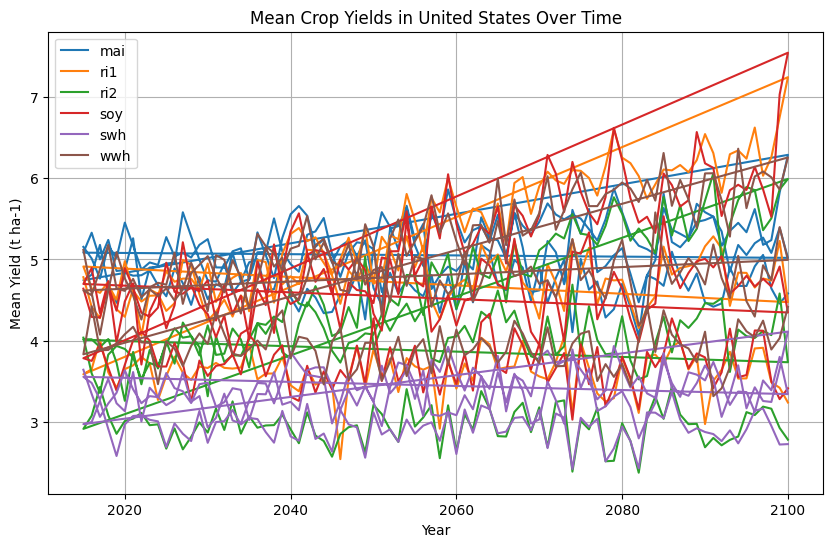


Processing region: Europe


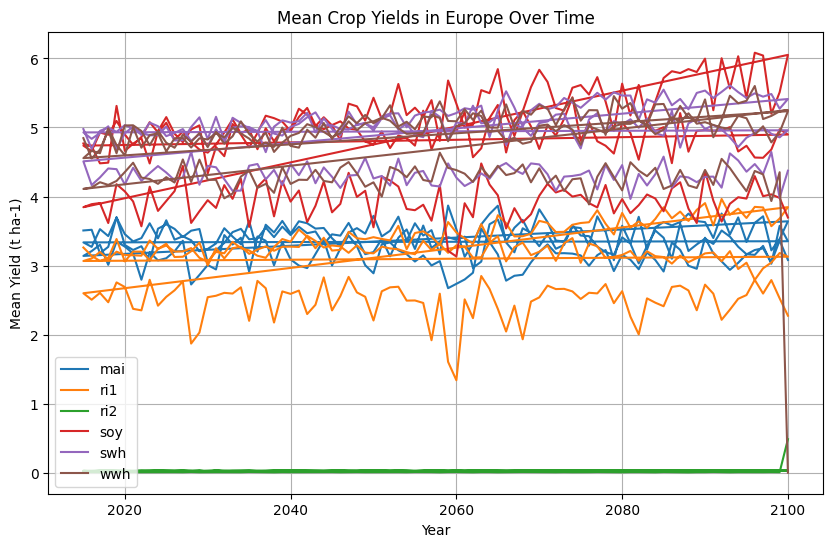


Processing region: Asia


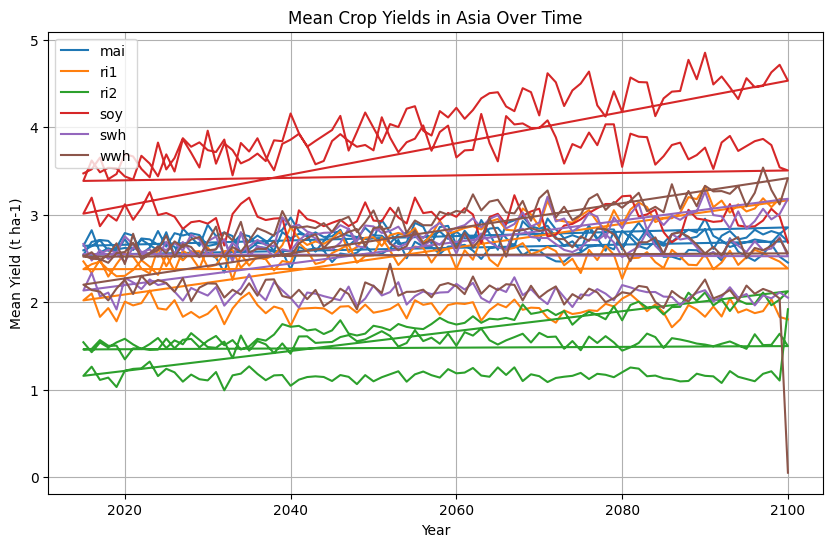


Processing region: Africa


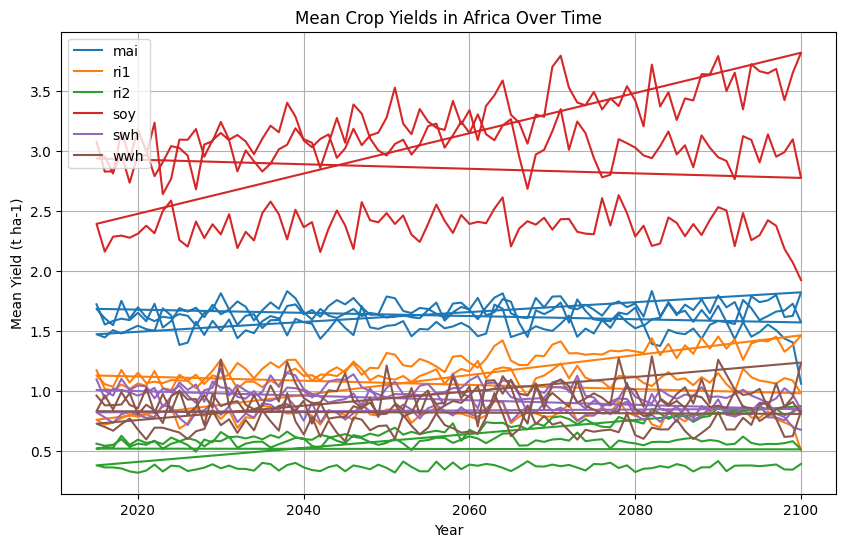

In [174]:
regions = {
    "United States": {"lat": slice(24, 49), "lon": slice(-125, -66)},
    "Europe": {"lat": slice(35, 71), "lon": slice(-25, 40)},  # Western Europe to Eastern Europe
    "Asia": {"lat": slice(5, 55), "lon": slice(60, 150)},  # Middle East to East Asia
    "Africa": {"lat": slice(-35, 37), "lon": slice(-20, 55)},  # Entire African continent
}

Ytrain = get_Ytrain(train_files)  # Load dataset

# Loop over each region
for region, coords in regions.items():
    print(f"\nProcessing region: {region}")

    # Select the region using `.where()` for flexibility
    lat_mask = (Ytrain.lat >= coords["lat"].start) & (Ytrain.lat <= coords["lat"].stop)
    lon_mask = (Ytrain.lon >= coords["lon"].start) & (Ytrain.lon <= coords["lon"].stop)
    Ytrain_region = Ytrain.where(lat_mask & lon_mask, drop=True)

    # Check if the region contains any data
    if Ytrain_region.to_array().isnull().all():
        print(f" Warning: No valid data available for {region}. Skipping plot.")
        continue  # Skip to the next region

    # Compute mean crop yields over lat/lon, handling NaNs
    region_crop_means = Ytrain_region.mean(dim=["lat", "lon"], skipna=True)

    # Plot mean crop yields over time
    plt.figure(figsize=(10, 6))
    for crop in region_crop_means.data_vars:
        if not region_crop_means[crop].isnull().all():  # Avoid plotting empty series
            plt.plot(region_crop_means.time, region_crop_means[crop], label=crop)

    plt.xlabel("Year")
    plt.ylabel("Mean Yield (t ha-1)")
    plt.title(f"Mean Crop Yields in {region} Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

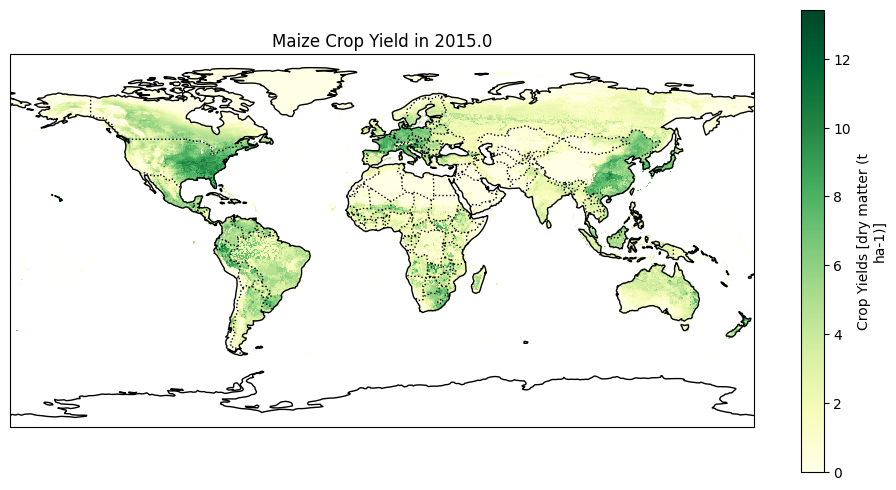

In [175]:
import cartopy.feature as cfeature

year_to_plot = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Maize Crop Yield in {year_to_plot.time.values}")
plt.show()

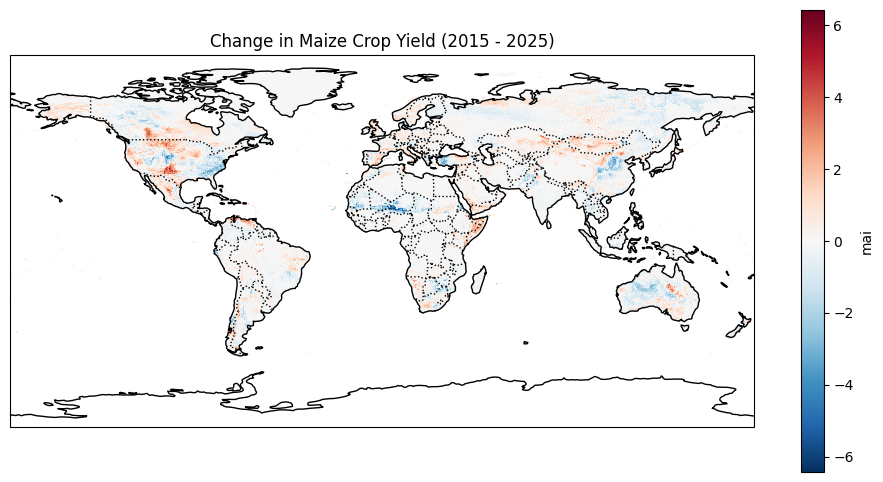

In [176]:
# Load crop yield data for 2015 and 2025
yields_2015 = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['mai'].sel(time=2025).isel(time=0)

# Compute the difference (Change in Yield: 2025 - 2015)
yield_change = yields_2025 - yields_2015

# Plot the difference map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Use a diverging colormap to highlight increases and decreases
cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add title and colorbar
plt.title("Change in Maize Crop Yield (2015 - 2025)")

# Show the plot
plt.show()

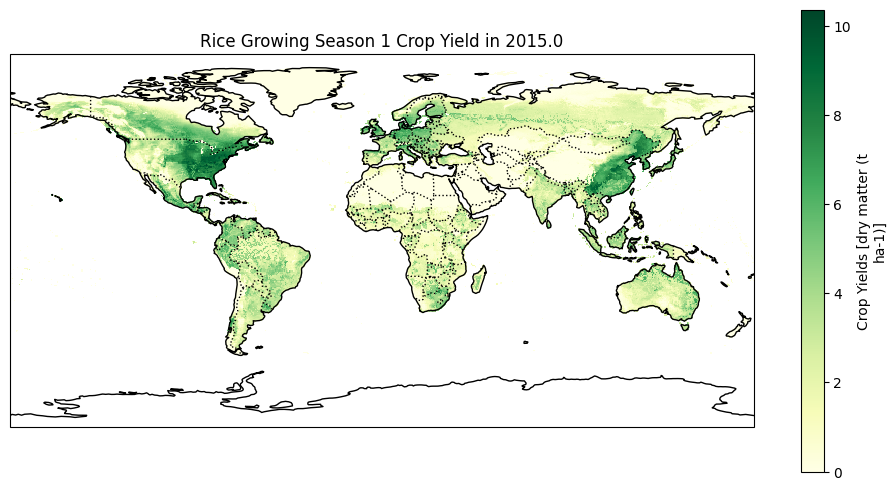

In [177]:
year_to_plot = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Rice Growing Season 1 Crop Yield in {year_to_plot.time.values}")
plt.show()

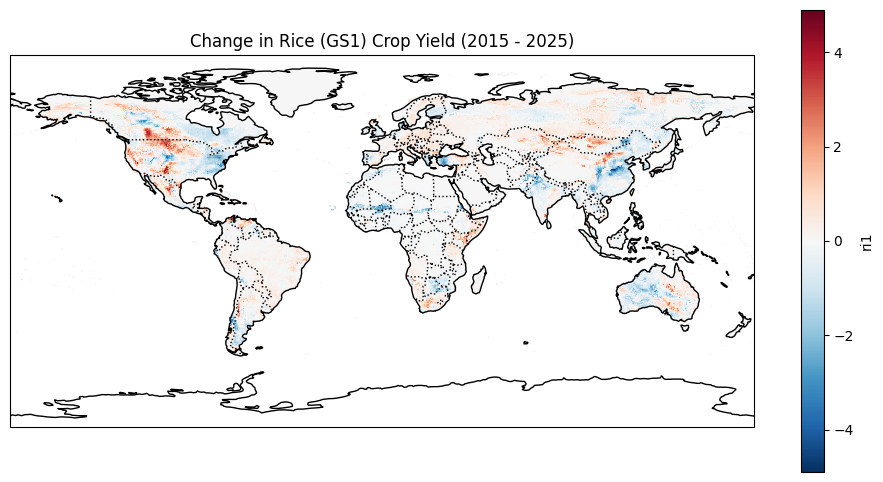

In [178]:
yields_2015 = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['ri1'].sel(time=2025).isel(time=0)

# Compute the difference (Change in Yield: 2025 - 2015)
yield_change = yields_2025 - yields_2015

# Plot the difference map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Use a diverging colormap to highlight increases and decreases
cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add title and colorbar
plt.title("Change in Rice (GS1) Crop Yield (2015 - 2025)")

# Show the plot
plt.show()

### Start of RF Modeling

In [179]:
#parameters dictionary
param_dict = {
    'mai': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri1': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri2': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'soy': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'swh': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'wwh': {
        'n_estimators': 250,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    }
}


### Running RF model for years 2015-2100 each crop 

In [215]:
os.makedirs("saved_models", exist_ok=True)


In [223]:
crop_variables = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh'] 

rf_models = {}  
predictions_dict = {} 

for crop in crop_variables:
    print(f"Processing crop: {crop}")

    # Process Ytrain: Average over lat/lon and reshape
    Ytrain_crop = get_Ytrain(train_files)[crop].mean(dim=['lat', 'lon'])
    Ytrain_crop = Ytrain_crop.values.reshape(-1, 1)

    # Process Ytest same as Ytrain
    Ytest_crop = Ytest[crop].mean(dim=['lat', 'lon'])
    Ytest_crop = Ytest_crop.values.reshape(-1, 1)

    # Training RF model
    rf = rf_model(
        Xtrain,
        Ytrain_crop.ravel(),  # Flatten for training
        random_state=0,
        bootstrap=True,
        max_features='sqrt',
        **param_dict[crop]  
    )
    rf.train()
    rf_models[crop] = rf  # Store trained model


    # **Save model parameters**
   # **Save model using joblib**
    model_path = f"saved_models/{crop}_rf_model.pkl"
    joblib.dump(rf.model, model_path)  # Save only `rf.model`
    print(f"Model saved: {model_path}")

    predictions = rf.predict(Xtest)
    predictions_array = predictions[0]

    # Convert to NumPy if it's an xarray DataArray
    if isinstance(predictions_array, xr.DataArray):
        predictions_array = predictions_array.values  

    print(f"{crop} Predictions Array Shape:", predictions_array.shape)

    # Make sure its 2D shape before computing mean
    if predictions_array.ndim == 1:
        predictions_final = predictions_array.reshape(-1, 1)
    else:
        predictions_final = predictions_array.mean(axis=1).reshape(-1, 1)

    print(f"Processed Predictions Shape for {crop}:", predictions_final.shape)

    # RMSE
    mse = mean_squared_error(Ytest_crop, predictions_final)
    print(f"Root Mean Squared Error (MSE) for {crop}: {np.sqrt(mse):}")

    # Store predictions
    predictions_dict[crop] = predictions_final

Processing crop: mai


/Users/nilaymenon/opt/anaconda3/envs/rf_env/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved: saved_models/mai_rf_model.pkl
mai Predictions Array Shape: (86,)
Processed Predictions Shape for mai: (86, 1)
Root Mean Squared Error (MSE) for mai: 0.07897531004332722
Processing crop: ri1


/Users/nilaymenon/opt/anaconda3/envs/rf_env/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved: saved_models/ri1_rf_model.pkl
ri1 Predictions Array Shape: (86,)
Processed Predictions Shape for ri1: (86, 1)
Root Mean Squared Error (MSE) for ri1: 0.207096091215544
Processing crop: ri2


...

Model saved: saved_models/soy_rf_model.pkl
soy Predictions Array Shape: (86,)
Processed Predictions Shape for soy: (86, 1)
Root Mean Squared Error (MSE) for soy: 0.27928953206849405
Processing crop: swh


/Users/nilaymenon/opt/anaconda3/envs/rf_env/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved: saved_models/swh_rf_model.pkl
swh Predictions Array Shape: (86,)
Processed Predictions Shape for swh: (86, 1)
Root Mean Squared Error (MSE) for swh: 0.13517808899889525
Processing crop: wwh


/Users/nilaymenon/opt/anaconda3/envs/rf_env/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved: saved_models/wwh_rf_model.pkl
wwh Predictions Array Shape: (86,)
Processed Predictions Shape for wwh: (86, 1)
Root Mean Squared Error (MSE) for wwh: 0.11359848478795957


### Running a small grid search 

In [181]:
# # Define a small grid of hyperparameters to test
# param_grid = {
#     'n_estimators': [100, 250],  # Number of trees
#     'min_samples_split': [2, 5],  # Min samples required to split a node
#     'min_samples_leaf': [3, 7],   # Min samples in a leaf node
#     'max_depth': [3, 5]           # Max depth of the trees
# }

# # Define the crops to model
# crop_variables = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh']

# rf_models = {}  
# predictions_dict = {}  
# best_params_dict = {}  # Store best parameters

# for crop in crop_variables:
#     print(f"Processing crop: {crop}")

#     # Process Ytrain: Average over lat/lon and reshape
#     Ytrain_crop = get_Ytrain(train_files)[crop].mean(dim=['lat', 'lon'])
#     Ytrain_crop = Ytrain_crop.values.reshape(-1, 1)

#     # Process Ytest
#     Ytest_crop = Ytest[crop].mean(dim=['lat', 'lon'])
#     Ytest_crop = Ytest_crop.values.reshape(-1, 1)

#     best_rmse = float("inf")  # Track best RMSE
#     best_params = None  # Track best parameter set
#     best_model = None  # Track best trained model

#     # Perform manual grid search over hyperparameters
#     for params in itertools.product(*param_grid.values()):
#         param_dict = dict(zip(param_grid.keys(), params))  # Convert tuple to dictionary

#         # Train RF model with current hyperparameters
#         rf = rf_model(
#             Xtrain,
#             Ytrain_crop.ravel(),  # Flatten for training
#             random_state=0,
#             bootstrap=True,
#             max_features='sqrt',
#             **param_dict  # Use selected parameters
#         )
#         rf.train()

#         # Predict
#         predictions = rf.predict(Xtest)
#         predictions_array = predictions[0]

#         # Convert to NumPy if it's an xarray DataArray
#         if isinstance(predictions_array, xr.DataArray):
#             predictions_array = predictions_array.values  

#         # Ensure 2D shape before computing mean
#         if predictions_array.ndim == 1:
#             predictions_final = predictions_array.reshape(-1, 1)
#         else:
#             predictions_final = predictions_array.mean(axis=1).reshape(-1, 1)

#         # Compute RMSE
#         mse = mean_squared_error(Ytest_crop, predictions_final)
#         rmse = np.sqrt(mse)

#         print(f"RMSE for {crop} with params {param_dict}: {rmse}")

#         # Update best parameters if current model is better
#         if rmse < best_rmse:
#             best_rmse = rmse
#             best_params = param_dict
#             best_model = rf

#     # Store best trained model and parameters
#     rf_models[crop] = best_model
#     best_params_dict[crop] = best_params

#     print(f"Best Parameters for {crop}: {best_params}")
#     print(f"Best RMSE for {crop}: {best_rmse}")

#     # final predictions with the best model
#     predictions = best_model.predict(Xtest)
#     predictions_array = predictions[0]

#     # Convert to NumPy 
#     if isinstance(predictions_array, xr.DataArray):
#         predictions_array = predictions_array.values  

#     if predictions_array.ndim == 1:
#         predictions_final = predictions_array.reshape(-1, 1)
#     else:
#         predictions_final = predictions_array.mean(axis=1).reshape(-1, 1)

#     predictions_dict[crop] = predictions_final